# Laboratorium 3 – Progowanie i segmentacja
**Analiza i przetwarzanie obrazów**  
AGH, Informatyka Stosowana II st., Semestr I

## a) Wczytanie obrazu i konwersja do skali szarości

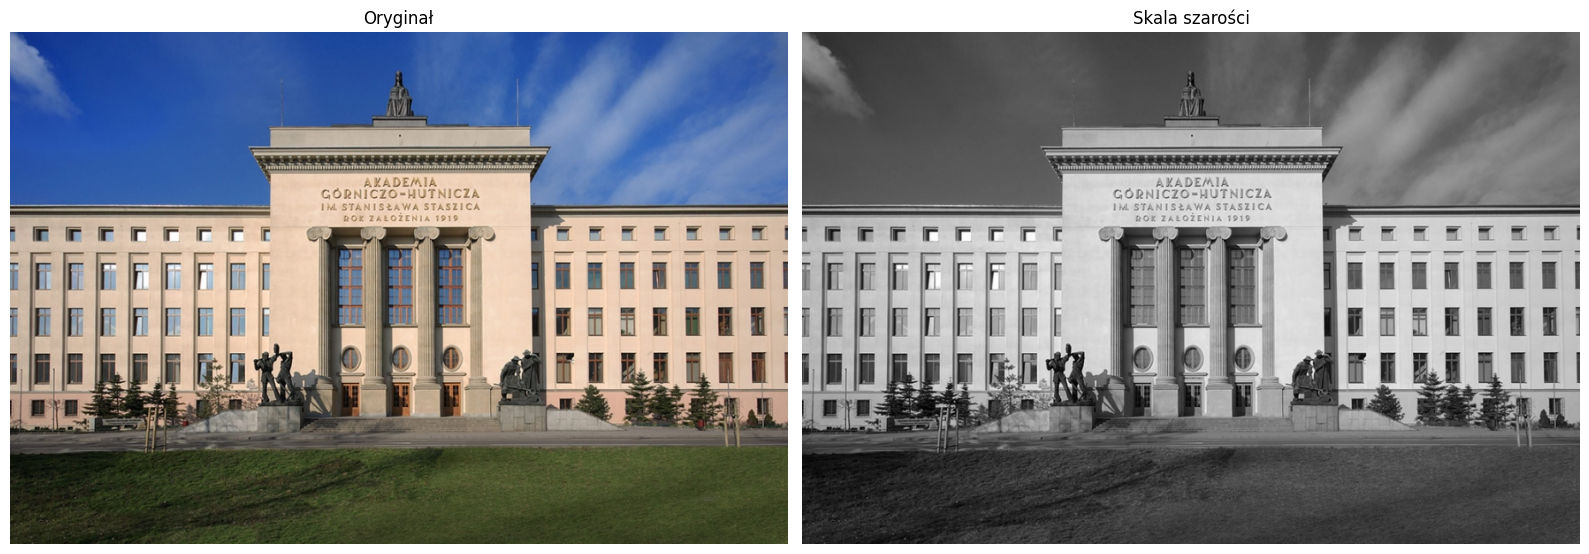

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

plt.rcParams['figure.figsize'] = [16, 8]

img_bgr = cv2.imread('../images/lab3_1.jpg')
img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2)
axes[0].imshow(img); axes[0].set_title('Oryginał'); axes[0].axis('off')
axes[1].imshow(gray, cmap='gray'); axes[1].set_title('Skala szarości'); axes[1].axis('off')
plt.tight_layout()
plt.show()

## b) Progowanie statyczne – porównanie trybów

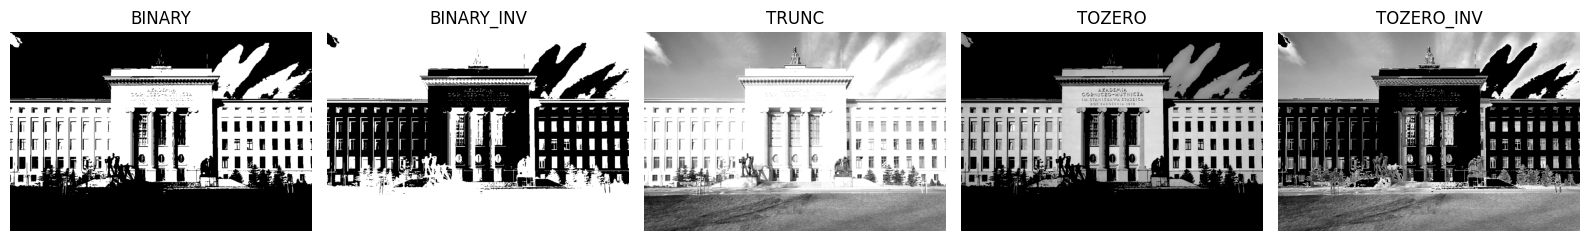

In [2]:
thresh_val = 127
modes = [cv2.THRESH_BINARY, cv2.THRESH_BINARY_INV, cv2.THRESH_TRUNC,
         cv2.THRESH_TOZERO, cv2.THRESH_TOZERO_INV]
names = ['BINARY', 'BINARY_INV', 'TRUNC', 'TOZERO', 'TOZERO_INV']

fig, axes = plt.subplots(1, 5)
for ax, mode, name in zip(axes, modes, names):
    _, th = cv2.threshold(gray, thresh_val, 255, mode)
    ax.imshow(th, cmap='gray'); ax.set_title(name); ax.axis('off')
plt.tight_layout()
plt.show()

## c) Adaptacyjne progowanie

Większy rozmiar bloku → próg wyznaczany na podstawie większego otoczenia → mniej czuły na lokalne wahania jasności, traci drobne detale. Mniejszy blok zachowuje lokalne szczegóły kosztem większej wrażliwości na szum.

**GAUSSIAN** daje łagodniejsze przejścia dzięki wagom rozkładu Gaussa – mniej artefaktów na krawędziach bloków niż **MEAN**.

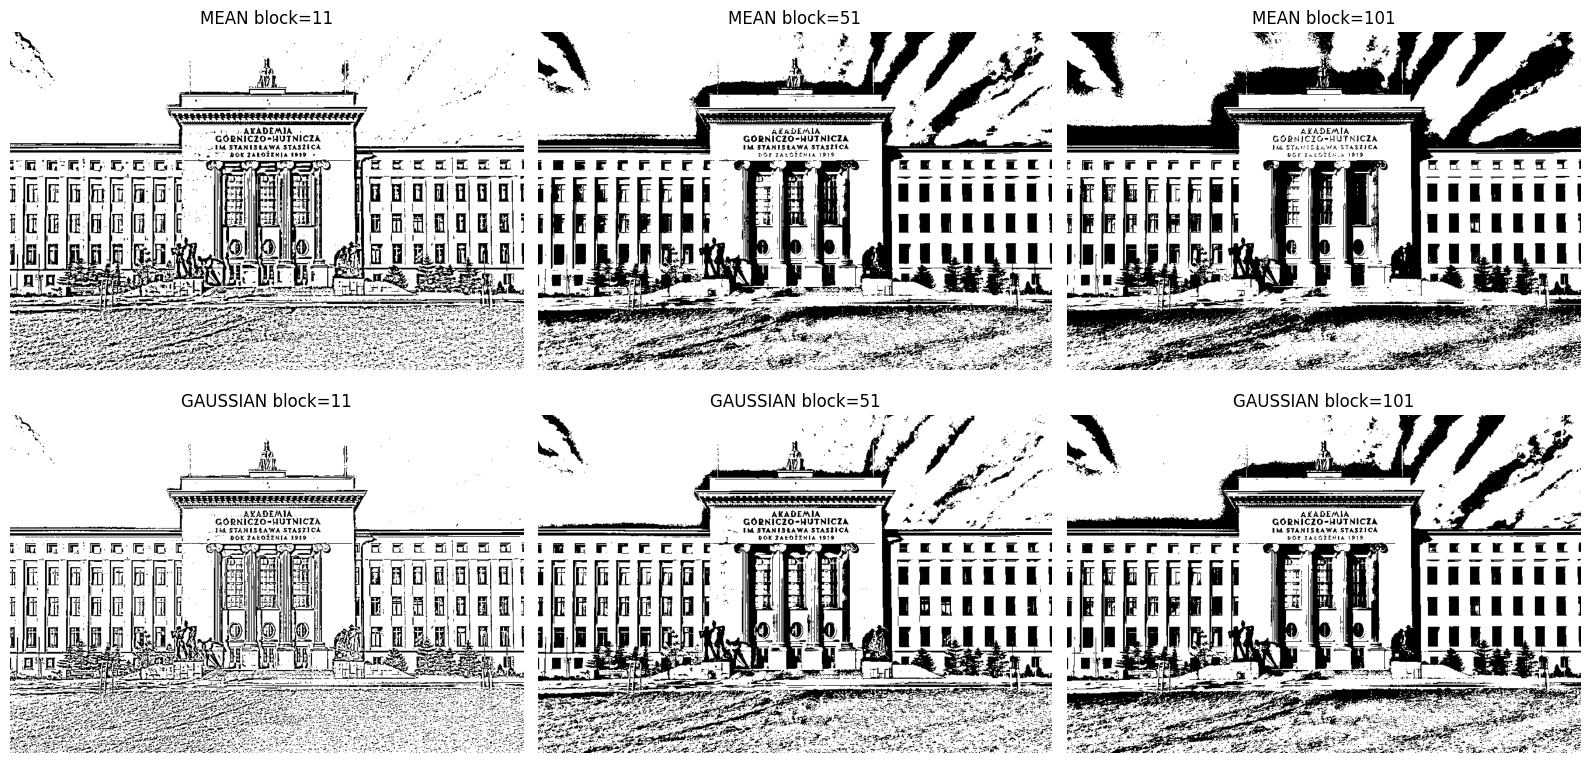

In [3]:
block_sizes = [11, 51, 101]
fig, axes = plt.subplots(2, 3)
for i, bs in enumerate(block_sizes):
    th_mean  = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C,     cv2.THRESH_BINARY, bs, 5)
    th_gauss = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, bs, 5)
    axes[0, i].imshow(th_mean,  cmap='gray'); axes[0, i].set_title(f'MEAN block={bs}');     axes[0, i].axis('off')
    axes[1, i].imshow(th_gauss, cmap='gray'); axes[1, i].set_title(f'GAUSSIAN block={bs}'); axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## d) Metoda Otsu – histogram z progiem

Próg Otsu: 133


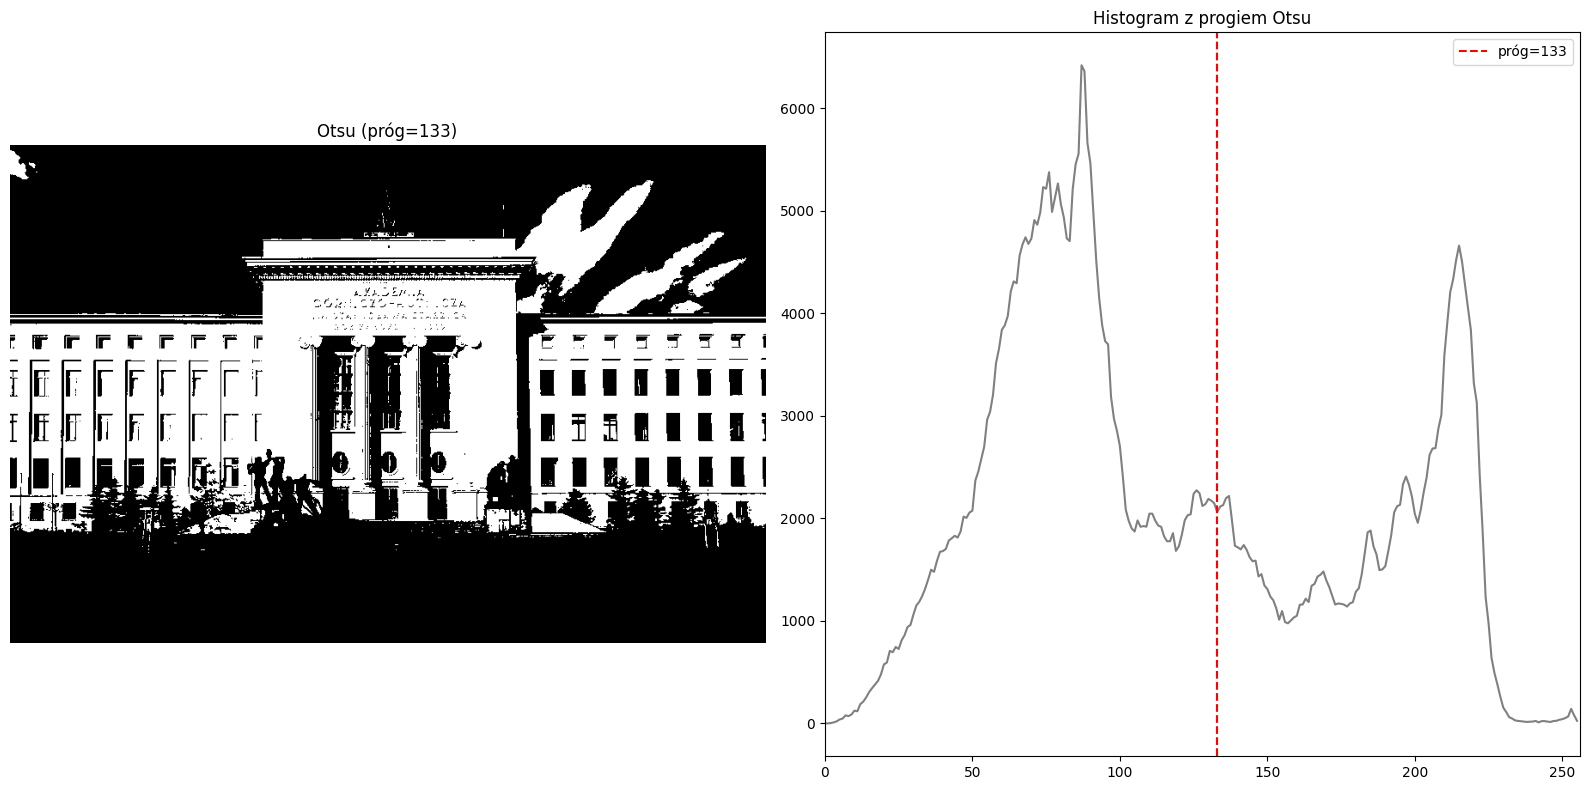

In [4]:
otsu_val, th_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Próg Otsu: {otsu_val:.0f}")

fig, axes = plt.subplots(1, 2)
axes[0].imshow(th_otsu, cmap='gray'); axes[0].set_title(f'Otsu (próg={otsu_val:.0f})'); axes[0].axis('off')
hist = cv2.calcHist([gray], [0], None, [256], [0, 256])
axes[1].plot(hist, color='gray')
axes[1].axvline(x=otsu_val, color='red', linestyle='--', label=f'próg={otsu_val:.0f}')
axes[1].set_title('Histogram z progiem Otsu')
axes[1].set_xlim([0, 256])
axes[1].legend()
plt.tight_layout()
plt.show()

## e) Segmentacja k-średnich (K=2, 4, 8)

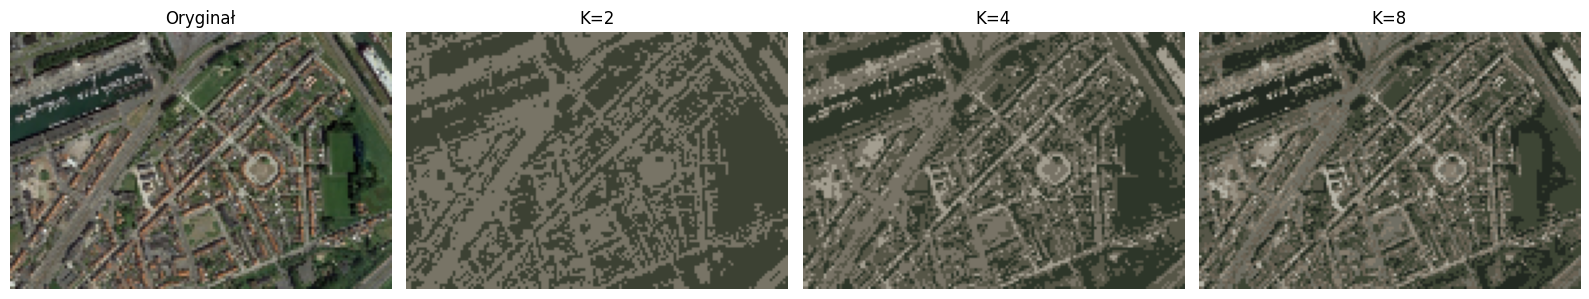

In [5]:
img2_bgr = cv2.imread('../images/lab3_2.png')
small = cv2.resize(img2_bgr, None, fx=0.3, fy=0.3)  # zmniejszenie dla szybkości
data = small.reshape(-1, 3).astype(np.float32)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)

fig, axes = plt.subplots(1, 4)
axes[0].imshow(cv2.cvtColor(small, cv2.COLOR_BGR2RGB)); axes[0].set_title('Oryginał'); axes[0].axis('off')
for i, K in enumerate([2, 4, 8]):
    _, labels, centers = cv2.kmeans(data, K, None, criteria, 3, cv2.KMEANS_RANDOM_CENTERS)
    seg = centers.astype(np.uint8)[labels.flatten()].reshape(small.shape)
    axes[i+1].imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB)); axes[i+1].set_title(f'K={K}'); axes[i+1].axis('off')
plt.tight_layout()
plt.show()

## f) Własna implementacja metody Otsu

Metoda Otsu maximalizuje wariancję międzyklasową: $\sigma_B^2(t) = w_0(t) \cdot w_1(t) \cdot [\mu_0(t) - \mu_1(t)]^2$

Wynik jest identyczny lub różni się o ±1 od implementacji OpenCV – różnica wynika wyłącznie z kolejności obsługi remisów (tie-breaking) przy jednakowej wariancji dla sąsiednich progów.

Własna implementacja: 134
cv2.THRESH_OTSU:      133


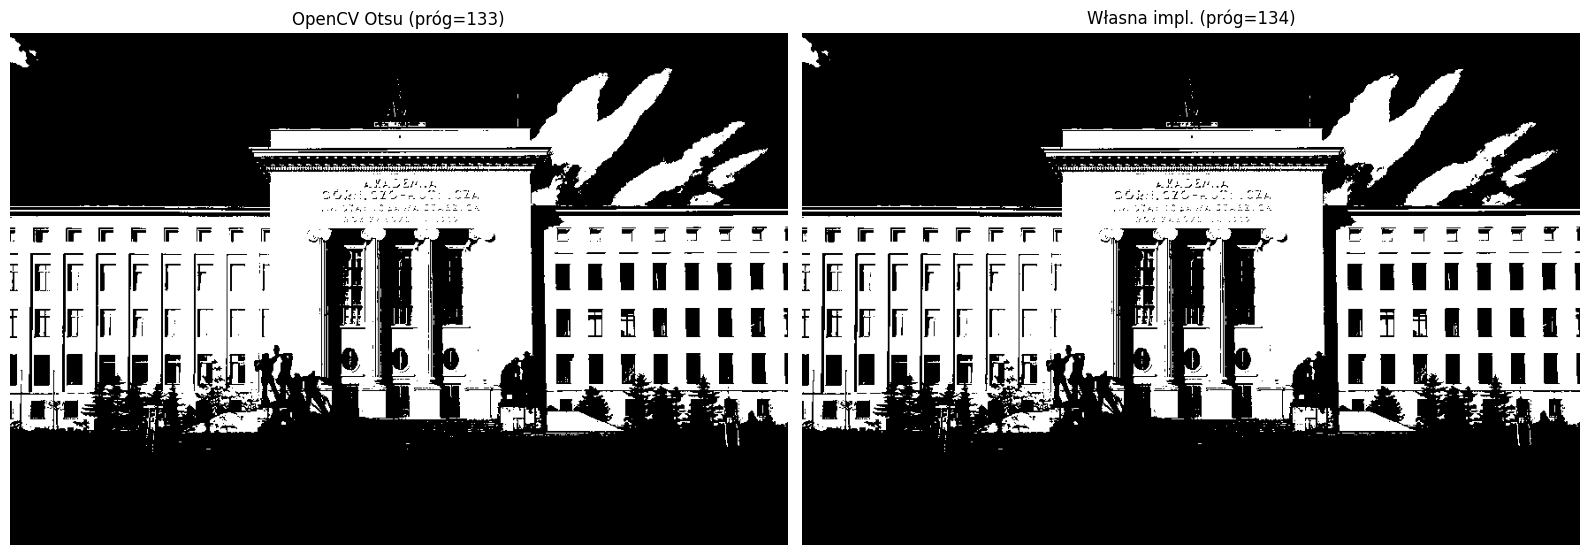

In [6]:
def otsu_impl(gray_img):
    prob = cv2.calcHist([gray_img], [0], None, [256], [0, 256]).flatten() / gray_img.size
    best_t, best_var = 0, 0
    for t in range(1, 256):
        w0, w1 = prob[:t].sum(), prob[t:].sum()
        if w0 == 0 or w1 == 0:
            continue
        mu0 = (np.arange(t)     * prob[:t]).sum() / w0
        mu1 = (np.arange(t,256) * prob[t:]).sum() / w1
        var = w0 * w1 * (mu0 - mu1) ** 2
        if var > best_var:
            best_var, best_t = var, t
    return best_t

my_thresh = otsu_impl(gray)
print(f"Własna implementacja: {my_thresh}")
print(f"cv2.THRESH_OTSU:      {int(otsu_val)}")

_, th_my = cv2.threshold(gray, my_thresh, 255, cv2.THRESH_BINARY)
fig, axes = plt.subplots(1, 2)
axes[0].imshow(th_otsu, cmap='gray'); axes[0].set_title(f'OpenCV Otsu (próg={int(otsu_val)})'); axes[0].axis('off')
axes[1].imshow(th_my,   cmap='gray'); axes[1].set_title(f'Własna impl. (próg={my_thresh})');    axes[1].axis('off')
plt.tight_layout()
plt.show()